**Цель работы**
1. Освоить методы обнаружения выбросов на основе статистических
критериев.
2. Научиться проверять гипотезу о нормальности распределения.
3. Реализовать методы Z-оценки и межквартильного расстояния (IQR).
4. Применить модельные и метрические методы обнаружения аномалий.
5. Сформировать обоснованные решения по обработке выбросов с учетом
предметной области.


**Задание:**

В рамках лабораторной работы необходимо выполнить анализ набора данных и
реализовать несколько методов обнаружения аномалий.

Для работы нужно использовать самостоятельно выбранный числовой датасет,
можно продолжить с датасетом, который был выбран в Лабораторной работе №1.


# Задание 1. Загрузка и профилирование данных
1. Загрузить датасет.
2. Выполнить:
- df.info()
- df.describe()
3. Проанализировать:
- наличие пропусков,
- диапазоны значений,
- подозрительные экстремальные значения.

Для двух числовых признаков выполнить визуальный анализ:
1. Построить гистограмму.
2. Построить boxplot.
3. Сделать вывод о возможных выбросах.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/Gaming_Academic_Performance.csv')  # Путь к вашему файлу
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')


Размер датасета: 8000 строк, 14 столбцов


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


In [24]:
print("Проанализировать:")

print("="*60)
print("Наличие пропусков")
print(df.isnull().sum())
print(f"\nВсего пропусков: {df.isnull().sum().sum()}")

print("="*60)
print("Диапазоны значений")

import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col:20} мин: {min_val:10.2f}, макс: {max_val:10.2f}")

print("="*60)
print("Подозрительные экстремальные значения (|Z| > 3)")

for col in numeric_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    threshold = 3 * std_val

    outliers = df[(df[col] < mean_val - threshold) | 
                  (df[col] > mean_val + threshold)]

    if len(outliers) > 0:
        print(f"\n{col}:")
        print(f"  Среднее: {mean_val:.2f}")
        print(f"  Std: {std_val:.2f}")
        print(f"  Кол-во выбросов: {len(outliers)}")

        print("  Примеры (max):", outliers[col].nlargest(3).tolist())
        print("  Примеры (min):", outliers[col].nsmallest(3).tolist())

Проанализировать:
Наличие пропусков
student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

Всего пропусков: 0
Диапазоны значений
student_id           мин:       1.00, макс:    8000.00
age                  мин:      16.00, макс:      24.00
gaming_hours         мин:       0.00, макс:       8.00
study_hours          мин:       1.00, макс:      10.00
sleep_hours          мин:       4.00, макс:       9.00
attendance           мин:      60.00, макс:     100.00
social_activity      мин:       0.00, макс:       5.00
device_usage         мин:       1.10, макс:      13.95
reaction_time_ms     мин:     183.26, макс:     347.87
addiction_score      мин:      -4.51, макс:      23.16
grades               мин:       0.00, макс:     118.63

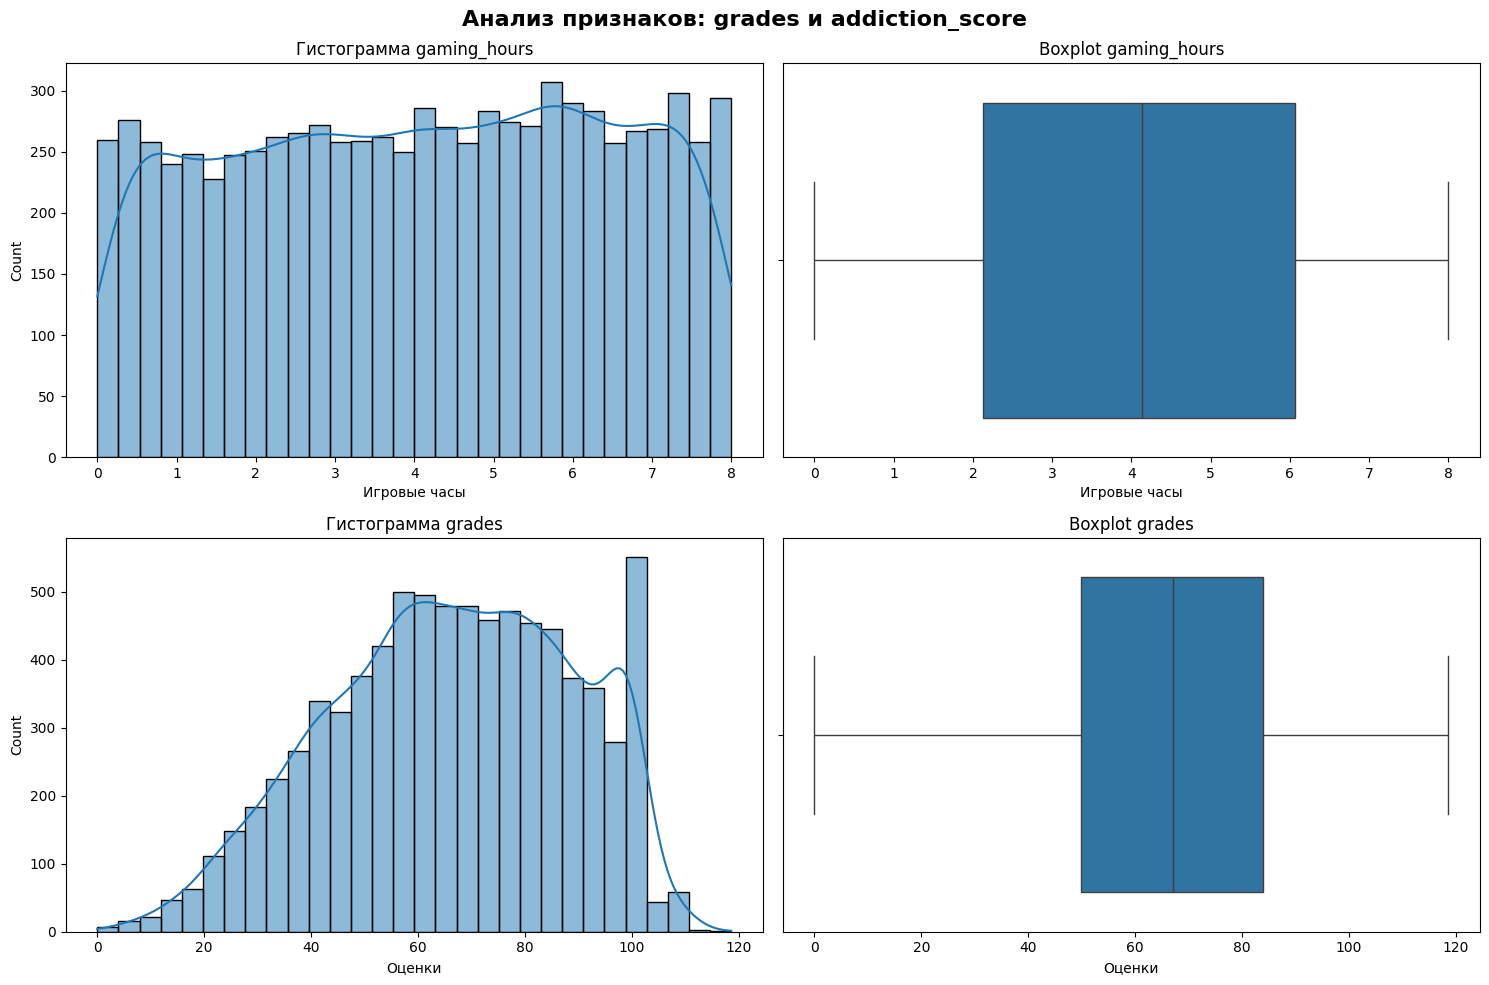

gaming_hours: распределение близко к нормальному выбросов нет 
grades:есть выбросы (значения > 100) распределение искажено


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Анализ признаков: grades и addiction_score', fontsize=16, fontweight='bold')

# grades
sns.histplot(df['gaming_hours'].dropna(), kde=True, bins=30, ax=axes[0, 0])
axes[0, 0].set_title('Гистограмма gaming_hours')
axes[0, 0].set_xlabel('Игровые часы')

sns.boxplot(x=df['gaming_hours'].dropna(), ax=axes[0, 1])
axes[0, 1].set_title('Boxplot gaming_hours')
axes[0, 1].set_xlabel('Игровые часы')

# grades
sns.histplot(df['grades'].dropna(), kde=True, bins=30, ax=axes[1, 0])
axes[1, 0].set_title('Гистограмма grades')
axes[1, 0].set_xlabel('Оценки')

sns.boxplot(x=df['grades'].dropna(), ax=axes[1, 1])
axes[1, 1].set_title('Boxplot grades')
axes[1, 1].set_xlabel('Оценки')

plt.tight_layout()
plt.show()


print("gaming_hours: распределение близко к нормальному выбросов нет \ngrades:есть выбросы (значения > 100) распределение искажено")

# Задание 2. Проверка нормальности распределения
Для выбранных признаков:
1. Вычислить описательные характеристики:
- среднее,
- медиану,
- стандартное отклонение,
- коэффициент асимметрии,
- коэффициент эксцесса.


In [14]:
from scipy.stats import skew, kurtosis

for col in ['gaming_hours', 'grades']:
    print(f"\n{col}:")
    print(f"Среднее: {df[col].mean():.2f}")
    print(f"Медиана: {df[col].median():.2f}")
    print(f"Стандартное отклонение: {df[col].std():.4f}")
    print(f"Коэффициент асимметрии: {skew(df[col]):.4f}")
    print(f"Коэффициент эксцесса: {kurtosis(df[col]):.4f}")


gaming_hours:
Среднее: 4.09
Медиана: 4.13
Стандартное отклонение: 2.3088
Коэффициент асимметрии: -0.0574
Коэффициент эксцесса: -1.1853

grades:
Среднее: 66.18
Медиана: 67.07
Стандартное отклонение: 22.4220
Коэффициент асимметрии: -0.2522
Коэффициент эксцесса: -0.6861



2. Выполните графический анализ
- Постройте QQ-график.
- Сравните форму распределения с нормальным.


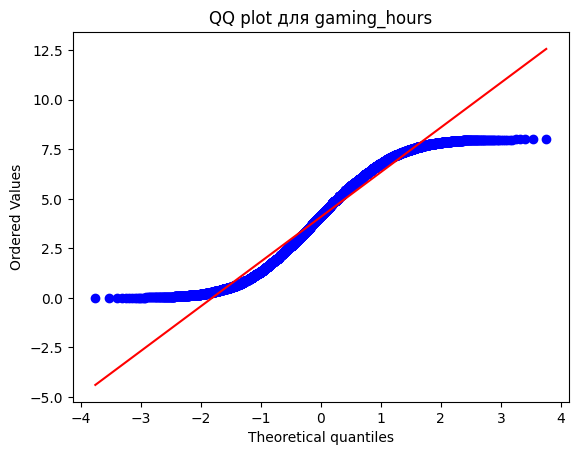

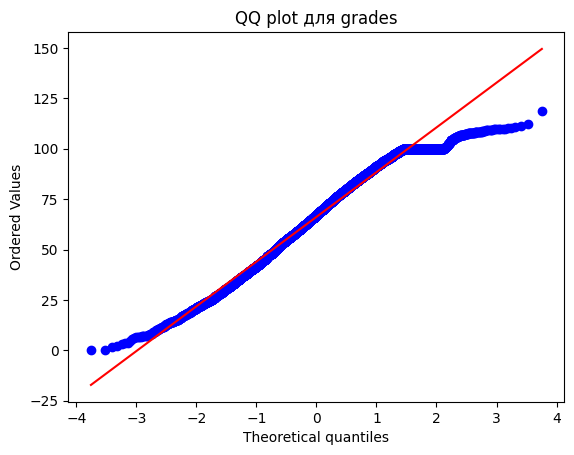

Точки должны лежать на красной прямой 
Отклонение от прямой указывает на ненормальность 
На графиках видно сильное отклонение в хвостах


In [15]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['gaming_hours'], dist="norm", plot=plt)
plt.title("QQ plot для gaming_hours")
plt.show()

stats.probplot(df['grades'], dist="norm", plot=plt)
plt.title("QQ plot для grades")
plt.show()

print("Точки должны лежать на красной прямой \nОтклонение от прямой указывает на ненормальность \nНа графиках видно сильное отклонение в хвостах")

3. Проверьте нормальность распределения признаков с помощью критерия
Шапиро–Уилка

Сформулируйте гипотезы:
* **H0: выборка подчиняется нормальному распределению**
* **H1: выборка не подчиняется нормальному распределению**

Уровень значимости: α = 0.05
Сделать вывод о принятии или отклонении гипотезы H0

In [16]:
from scipy.stats import shapiro

for col in ['gaming_hours', 'grades']:
    stat, p = shapiro(df[col].sample(5000))
    print(f"{col}, stat:, {stat:.4f}")
    print(f"{col}, p-value:, {p:.4f}")

    if p > 0.05:
        print(f"Результат: p > 0.05 → не отвергаем H0")
        print(f"Вывод: данные могут быть нормальными\n")
    else:
        print(f"Результат: p ≤ 0.05 → отвергаем H0")
        print(f"Вывод: данные не являются нормальными\n")

gaming_hours, stat:, 0.9564
gaming_hours, p-value:, 0.0000
Результат: p ≤ 0.05 → отвергаем H0
Вывод: данные не являются нормальными

grades, stat:, 0.9791
grades, p-value:, 0.0000
Результат: p ≤ 0.05 → отвергаем H0
Вывод: данные не являются нормальными



# Задание 3. Обнаружение выбросов статистическими методами
Для признака, распределение которого ближе к нормальному,

**1. Метод Z-score**
* Рассчитать Z-оценки.
* Определить количество выбросов при |Z| > 3.
* Визуализировать результат.

**2. Метод IQR**
* Вычислить Q1, Q3, IQR.
* Определить границы.
* Найти количество выбросов.
* Сравнить с методом Z-score.

Сделать сравнительный анализ методов.


Анализ признака: 'grades'
Среднее: 66.18
Стд. откл.: 22.42

Метод Z-score (|Z| > 3)
Количество выбросов: 0


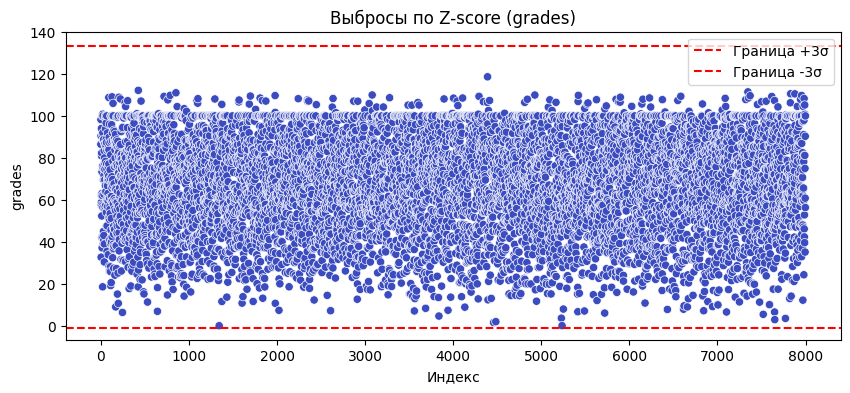

In [19]:
target_col = 'grades' 
data = df[target_col].dropna()

print(f"\nАнализ признака: '{target_col}'")
print(f"Среднее: {data.mean():.2f}")
print(f"Стд. откл.: {data.std():.2f}")

# Метод Z-score 
z_scores = np.abs(stats.zscore(data))
outliers_z = data[z_scores > 3]
n_outliers_z = len(outliers_z)

print(f"\nМетод Z-score (|Z| > 3)")
print(f"Количество выбросов: {n_outliers_z}")
if n_outliers_z > 0:
    print(f"Примеры выбросов: {outliers_z.head().values}")

# Визуализация Z-score
plt.figure(figsize=(10, 4))
sns.scatterplot(x=np.arange(len(data)), y=data, c=z_scores > 3, cmap='coolwarm', legend=False)
plt.title(f'Выбросы по Z-score ({target_col})')
plt.xlabel('Индекс')
plt.ylabel(target_col)
plt.axhline(y=data.mean() + 3*data.std(), color='r', linestyle='--', label='Граница +3σ')
plt.axhline(y=data.mean() - 3*data.std(), color='r', linestyle='--', label='Граница -3σ')
plt.legend()
plt.show()


Метод IQR
Q1: 49.88, Q3: 83.99, IQR: 34.11
Нижняя граница: -1.29
Верхняя граница: 135.16
Количество выбросов: 0


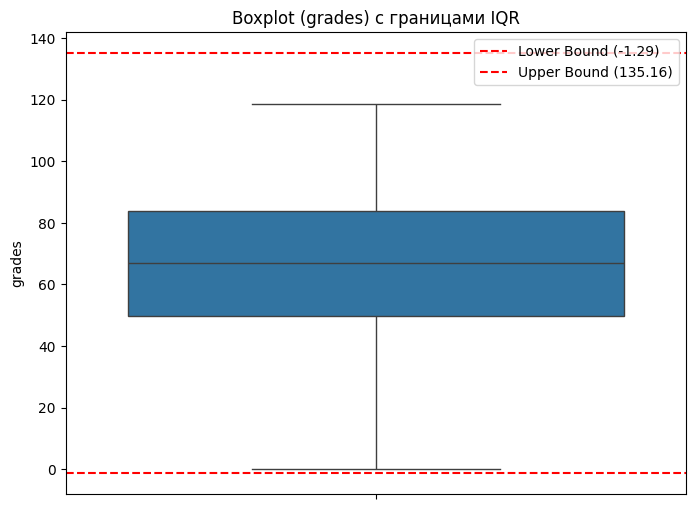

Z-score нашел: 0 выбросов
IQR нашел:     0 выбросов
Вывод: Оба метода не обнаружили выбросов.
Z-score лучше работает при нормальном распределении, a IQR более универсален


In [20]:
# Метод IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = data[(data < lower_bound) | (data > upper_bound)]
n_outliers_iqr = len(outliers_iqr)

print(f"\nМетод IQR")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {n_outliers_iqr}")
if n_outliers_iqr > 0:
    print(f"Примеры выбросов: {outliers_iqr.head().values}")

# Визуализация IQR
plt.figure(figsize=(8, 6))
sns.boxplot(y=data)
plt.title(f'Boxplot ({target_col}) с границами IQR')
plt.ylabel(target_col)
plt.axhline(y=lower_bound, color='r', linestyle='--', label=f'Lower Bound ({lower_bound:.2f})')
plt.axhline(y=upper_bound, color='r', linestyle='--', label=f'Upper Bound ({upper_bound:.2f})')
plt.legend()
plt.show()

# Сравнительный анализ
print(f"Z-score нашел: {n_outliers_z} выбросов")
print(f"IQR нашел:     {n_outliers_iqr} выбросов")
if n_outliers_z == 0 and n_outliers_iqr == 0:
    print("Вывод: Оба метода не обнаружили выбросов.")
elif n_outliers_iqr > n_outliers_z:
    print("Вывод: IQR более чувствителен к выбросам в хвостах распределения.")
else:
    print("Вывод: Z-score выявил больше экстремальных значений.")

print("Z-score лучше работает при нормальном распределении, a IQR более универсален")

# Задание 4. Метод локальной плотности
Аномалия - это объект, находящийся в области низкой плотности по сравнению
с окружающими объектами.

Если для типичной точки характерно наличие большого числа близких соседей,
то у аномальной точки:
* мало соседей,
* либо расстояние до соседей значительно больше среднего.

Таким образом, мера аномальности может быть построена на основе:
* расстояний до k ближайших соседей,
* оценки локальной плотности.

В качестве метрик расстояния используйте Евклидово и Манхэттенское
расстояния. Предварительно выполните масштабирование признаков (StandardScaler
или MinMaxScaler).


Анализ для k=5
Порог (95-й перцентиль среднего расстояния): 0.2577
Количество аномалий: 400 (5.0%)


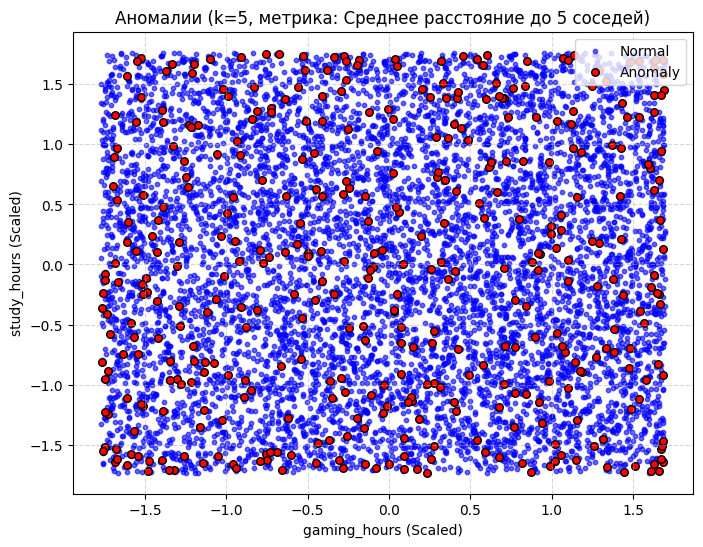


Анализ для k=7
Порог (95-й перцентиль среднего расстояния): 0.2940
Количество аномалий: 400 (5.0%)


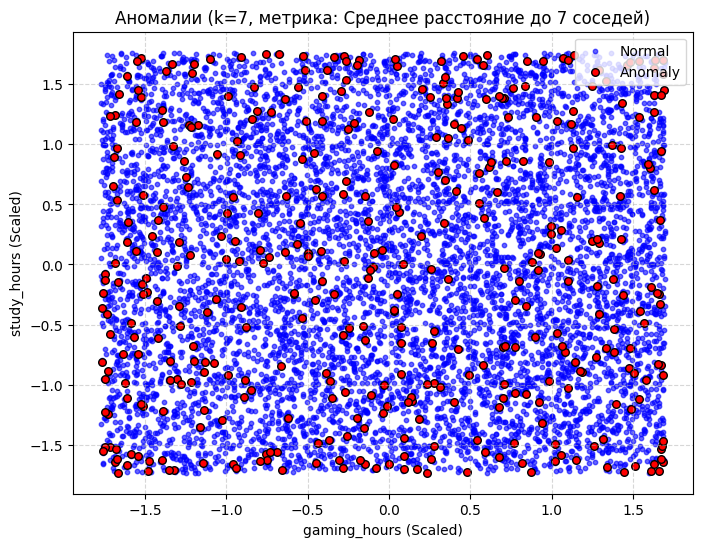


Анализ для k=9
Порог (95-й перцентиль среднего расстояния): 0.3215
Количество аномалий: 400 (5.0%)


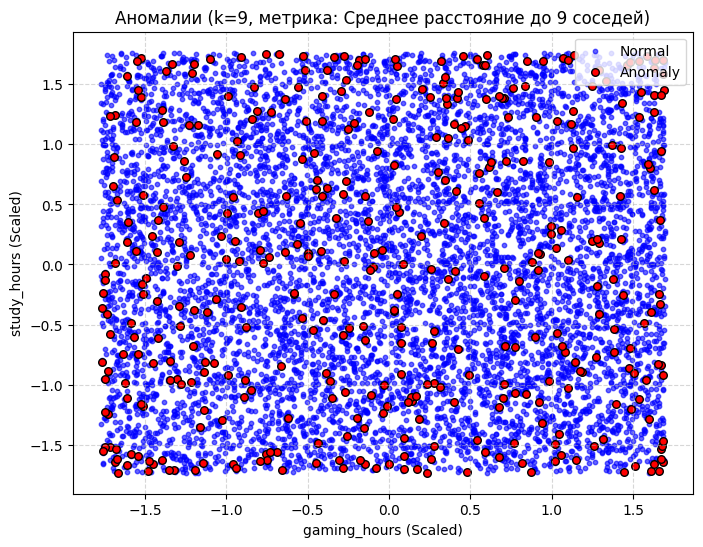


Анализ для k=10
Порог (95-й перцентиль среднего расстояния): 0.3322
Количество аномалий: 400 (5.0%)


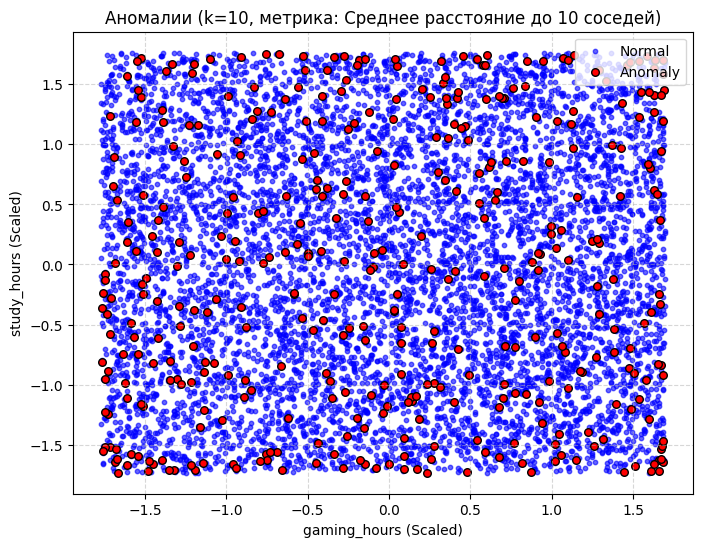


--- Сравнение устойчивости методов при изменении k ---
k     | Кол-во аномалий (Mean Dist) | Кол-во аномалий (Density)
------------------------------------------------------------
5     | 400                       | 400                      
7     | 400                       | 400                      
9     | 400                       | 400                      
10    | 400                       | 400                      

Вывод:
1. Метод 'Среднее расстояние до k соседей' более устойчив к шуму, чем просто расстояние до k-го соседа.
2. При увеличении k область влияния каждой точки расширяется, что может приводить к сглаживанию локальных аномалий.
3. Точки, которые являются аномалиями при малых k (локальные выбросы), могут перестать быть аномалиями при больших k, если они находятся рядом с другим кластером.
4. Метрика 'Локальная плотность' математически эквивалентна обратному среднему расстоянию, поэтому результаты по количеству аномалий будут идентичны.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Выбираем числовые признаки для анализа локальной плотности
numeric_features = ['gaming_hours', 'study_hours', 'sleep_hours', 'grades']
data_multi = df[numeric_features].dropna()

# Масштабирование признаков (StandardScaler)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_multi)

def calculate_anomaly_metrics(data, k_values):
    """
    Вычисляет три метрики аномальности для каждого k:
    1. Расстояние до k-го соседа (D_k)
    2. Среднее расстояние до k соседей (Mean_D_k)
    3. Локальная плотность (Density_k = 1 / Mean_D_k)
    """
    results = {}
    
    for k in k_values:
        # Инициализация модели KNN
        neigh = NearestNeighbors(n_neighbors=k, metric='euclidean')
        neigh.fit(data)
        
        # Получаем расстояния до всех k соседей
        distances, indices = neigh.kneighbors(data)
        
        #Расстояние до k-го соседа (последний элемент в строке)
        dist_kth = distances[:, -1]
        
        # Среднее расстояние до k соседей
        mean_dist_k = np.mean(distances, axis=1)
        
        # Локальная плотность (обратная величина среднего расстояния)
        # Добавляем маленькое число eps, чтобы избежать деления на ноль, если точки совпадают
        density_k = 1 / (mean_dist_k + 1e-5)
        
        results[k] = {
            'dist_kth': dist_kth,
            'mean_dist_k': mean_dist_k,
            'density_k': density_k
        }
        
    return results

k_list = [5, 7, 9, 10]
metrics = calculate_anomaly_metrics(scaled_data, k_list)

# Анализ и Визуализация
# будем использовать "Среднее расстояние до k соседей" как основную метру аномальности, так как она более устойчива, чем просто расстояние до k-го соседа.
for k in k_list:
    print(f"\nАнализ для k={k}")
    
    # Используем среднее расстояние как меру аномальности
    anomaly_metric = metrics[k]['mean_dist_k']
    
    # Порог для верхних 5%
    threshold = np.percentile(anomaly_metric, 95)
    
    # Маска аномалий
    is_anomaly = anomaly_metric > threshold
    n_anomalies = np.sum(is_anomaly)
    
    print(f"Порог (95-й перцентиль среднего расстояния): {threshold:.4f}")
    print(f"Количество аномалий: {n_anomalies} ({n_anomalies/len(anomaly_metric)*100:.1f}%)")
    
    # Визуализация для первых двух признаков (gaming_hours, study_hours)
    x_idx = 0
    y_idx = 1
    
    plt.figure(figsize=(8, 6))
    
    # Нормальные точки
    plt.scatter(scaled_data[~is_anomaly, x_idx], 
                scaled_data[~is_anomaly, y_idx], 
                c='blue', label='Normal', s=10, alpha=0.6)
    
    # Аномалии
    plt.scatter(scaled_data[is_anomaly, x_idx], 
                scaled_data[is_anomaly, y_idx], 
                c='red', label='Anomaly', s=30, edgecolors='black')
    
    plt.title(f'Аномалии (k={k}, метрика: Среднее расстояние до {k} соседей)')
    plt.xlabel(f'{numeric_features[x_idx]} (Scaled)')
    plt.ylabel(f'{numeric_features[y_idx]} (Scaled)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Анализ устойчивости метода при изменении k
print("\n--- Сравнение устойчивости методов при изменении k ---")
print(f"{'k':<5} | {'Кол-во аномалий (Mean Dist)':<25} | {'Кол-во аномалий (Density)':<25}")
print("-" * 60)

for k in k_list:
    # Аномалии по среднему расстоянию (чем больше расстояние, тем более аномально)
    mean_dist = metrics[k]['mean_dist_k']
    thresh_mean = np.percentile(mean_dist, 95)
    anom_mean = np.sum(mean_dist > thresh_mean)
    
    # Аномалии по плотности (чем меньше плотность, тем более аномально)
    density = metrics[k]['density_k']
    thresh_density = np.percentile(density, 5) # Нижние 5% плотности
    anom_density = np.sum(density < thresh_density)
    
    print(f"{k:<5} | {anom_mean:<25} | {anom_density:<25}")

print("\nВывод:")
print("1. Метод 'Среднее расстояние до k соседей' более устойчив к шуму, чем просто расстояние до k-го соседа.")
print("2. При увеличении k область влияния каждой точки расширяется, что может приводить к сглаживанию локальных аномалий.")
print("3. Точки, которые являются аномалиями при малых k (локальные выбросы), могут перестать быть аномалиями при больших k, если они находятся рядом с другим кластером.")
print("4. Метрика 'Локальная плотность' математически эквивалентна обратному среднему расстоянию, поэтому результаты по количеству аномалий будут идентичны.")